# Introduction
This notebook provides all the necessary code to obtain rank-four perfect tensors in local dimension 6. The solutions are obtained in terms of special $36\times 36$ unitary matrices (also called 2-unitary matrices) that are equivalent to absolutely maximally entangled states of four quhexes; AME(4,6). The perfect tensors obtained have only real-valued entries and are sparse having only 60 non-zero entries out of total $6^4=1296$. 

A four-legged tensor $T_{k,l,m,n}$ (with each index taking values from 0 to $d-1$ for a given local dimension $d$) is perfect iff the following $d^2 \times d^2$ matrices are all unitary:
* $U:\;U_{k,l}^{m,n}:=\langle m,n|T|k,l\rangle$. (Normal Unitarity)
* $U_R:\;\langle m,n|U_R|k,l\rangle:=\langle m,k|U|n,l\rangle$. (Realignment unitarity) 
* $U_T:\;\langle m,n|U_T|k,l\rangle:=\langle m,l|U|k,n\rangle$. (Partial transpose unitarity)

The most important step in our method is to start the numerical search for perfect tensors with structured seed unitaries that remain invariant under the realignment and partial transpose operations. We classify all such unitaries in an upcoming paper and here we illustarte our method by choosing one such family of seed unitaries.

In [24]:
##Load necessary packages
from scipy.stats import unitary_group,ortho_group,special_ortho_group
import numpy as np
from numpy import pi,log,exp,sqrt,cos,sin
from numpy import linalg as la
from scipy.linalg import polar
from scipy.optimize import minimize
import matplotlib.pyplot as plt

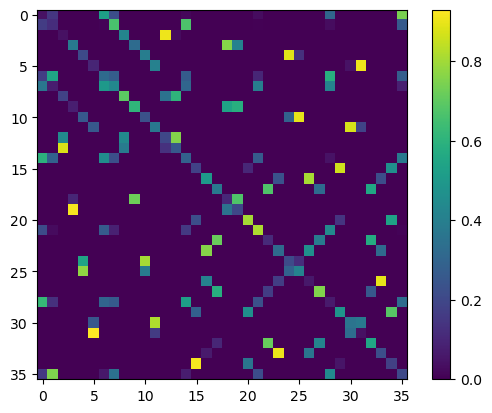

In [25]:
d=6      # local dimension

def seed_unitary():
    # 36x26 adjacency matrix of the seed unitary: 1 means non-zero entry is allowed
    Adj_mat= np.array([
    [1., 1., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1.],
    [1., 1., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1.],
    [0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0.],
    [1., 1., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1.],
    [1., 1., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1.],
    [0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0.],
    [0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
    [1., 1., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1.],
    [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0.],
    [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
    [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0.],
    [0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0.],
    [1., 1., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1.],
    [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0.],
    [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
    [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
    [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0.],
    [1., 1., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1.],
    [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0.],
    [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0.],
    [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0.],
    [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0.],
    [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
    [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0.],
    [1., 1., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1.]
                                ])   
    Ran_seed=np.zeros([d**2,d**2],dtype=float)
    for k in range(d**2):
        for l in range(d**2):
            if 1-1e-10<Adj_mat[k][l]<1+1e-10:
                Ran_seed[k][l]=np.random.randn()     ##real number add 1j*np.random.randn() for complex seeds
    U_seed=polar(Ran_seed)[0]       # polar decomposition to obtain random orthogonal matrix of size 36 with given zero pattern
    return U_seed
plt.imshow(abs(seed_unitary()))
plt.colorbar()
plt.show()

# Iterative algorithm for perfect tensors [Rather et al. PRL 125 (7), 070501 (2020)]
* Structured seed unitary: $U_0 \in \mathbb{U}(d^2)$.
* $R$ and $T$ involutions: $U_0 \mapsto (U_0)_R \mapsto W_0:=((U_0)_R)_T$.
* Projection to the unitary group: $W_0 \mapsto U_1 \in \mathbb{U}(d^2)$.
  
Iterate with $U_1$ such that for large number of iterations, $U_n$ is close to a perfect tensor.

In [29]:
## Polar decomposition to obtain perfect tensors from random seeds from Rather et al. Physical Review Letters 125 (7), 070501 (2020)
def polar_decom_map_perf_tensors(U_0,n):
    #U_0: seed unitary, n: number of iterations 
    d=int(sqrt(np.shape(U_0)[0]))
    for _ in range(n):
        U_0R=U_0.reshape([d,d,d,d]).transpose([0,2,1,3]).reshape(d**2,d**2)       # Realignment
        U_0RG=U_0R.reshape([d,d,d,d]).transpose([0,3,2,1]).reshape(d**2,d**2)     # Partial transpose
        U_1=polar(U_0RG)[0] # Uniquely defined as long as U_0RG is of full rank. In rank defiicent cases make sure the structure is preserved       
        U_0=U_1
    return U_1
    
## Deviation of a given unitary from being a perfect tensor
def defect_perf_tensor(U):
    d=int(sqrt(np.shape(U)[0]))
    U_R=U.reshape([d,d,d,d]).transpose([0,2,1,3]).reshape(d**2,d**2)
    U_G=U.reshape([d,d,d,d]).transpose([0,3,2,1]).reshape(d**2,d**2)
    Del_U=la.norm(U@np.conj(U.T)-np.eye(d**2))
    Del_UR=la.norm(U_R@np.conj(U_R.T)-np.eye(d**2))
    Del_UG=la.norm(U_G@np.conj(U_G.T)-np.eye(d**2))
    Defect=Del_U+Del_UR+Del_UG
    return Defect

#################### real-valued perfect tensor is obtained numercially ###############################
||la.norm(UU^{\dagger}-I_36||=  6.747556503281034e-15
||la.norm(U_RU_R^{\dagger}-I_36||=  1.5218124311831516e-14
||la.norm(U_GU_G^{\dagger}-I_36||=  1.6056169605737018e-14


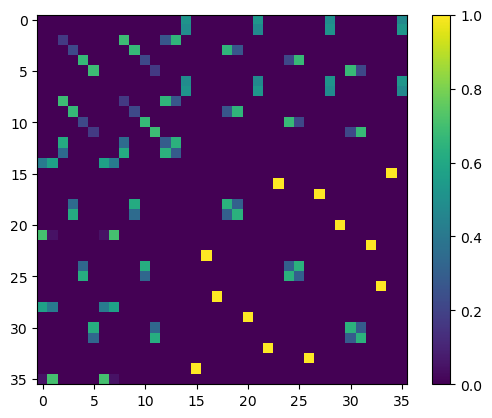

  
#################### real-valued perfect tensor is obtained numercially ###############################
||la.norm(UU^{\dagger}-I_36||=  6.163142137274931e-15
||la.norm(U_RU_R^{\dagger}-I_36||=  1.420571110386018e-14
||la.norm(U_GU_G^{\dagger}-I_36||=  1.5090419460463136e-14


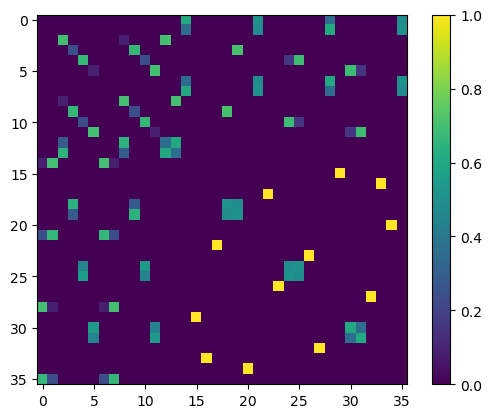

  
#################### real-valued perfect tensor is obtained numercially ###############################
||la.norm(UU^{\dagger}-I_36||=  6.858339530532843e-15
||la.norm(U_RU_R^{\dagger}-I_36||=  1.507949160757433e-14
||la.norm(U_GU_G^{\dagger}-I_36||=  1.4973155136942673e-14


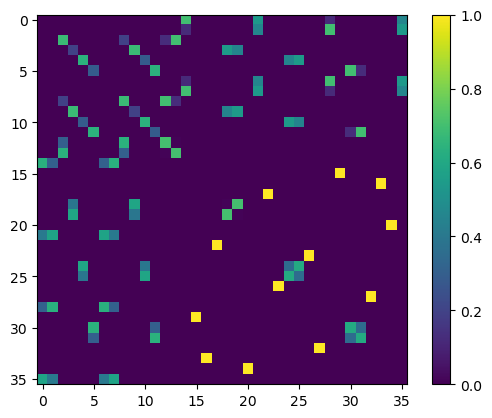

  
#################### real-valued perfect tensor is obtained numercially ###############################
||la.norm(UU^{\dagger}-I_36||=  6.4370157623930165e-15
||la.norm(U_RU_R^{\dagger}-I_36||=  1.5764531242737315e-14
||la.norm(U_GU_G^{\dagger}-I_36||=  1.706257582215583e-14


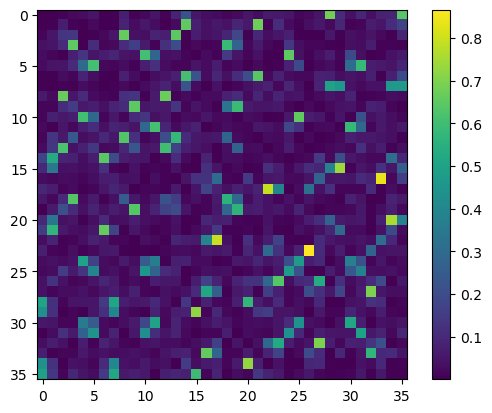

  
#################### real-valued perfect tensor is obtained numercially ###############################
||la.norm(UU^{\dagger}-I_36||=  5.869627975185974e-15
||la.norm(U_RU_R^{\dagger}-I_36||=  1.483607932207977e-14
||la.norm(U_GU_G^{\dagger}-I_36||=  1.632168035071051e-14


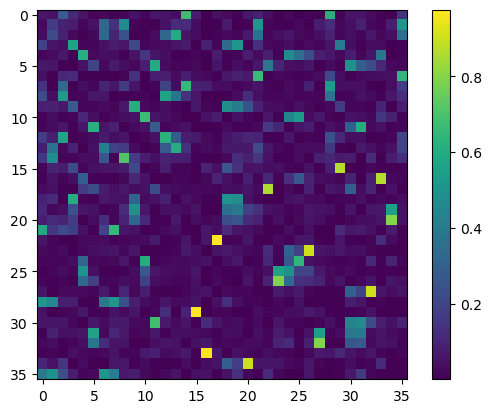

  
#################### real-valued perfect tensor is obtained numercially ###############################
||la.norm(UU^{\dagger}-I_36||=  6.8533943717981626e-15
||la.norm(U_RU_R^{\dagger}-I_36||=  1.4746155015415543e-14
||la.norm(U_GU_G^{\dagger}-I_36||=  1.623012448338709e-14


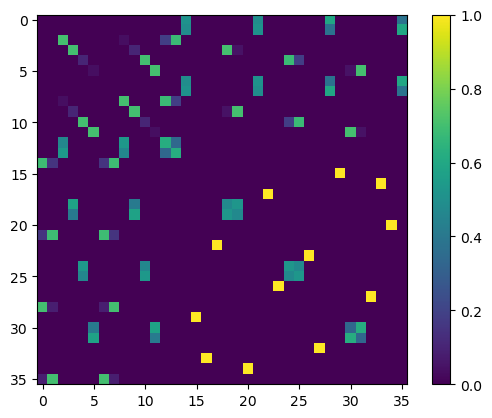

In [28]:
##Let us try ensemble of seed unitaries and apply the above map to generate random perfect tensors
d=6                                           # local dimension
n=1000                                        # Number of iterations
for _ in range(500):
    U_0=seed_unitary()
    U=polar_decom_map_perf_tensors(U_0,n)
    defect=defect_perf_tensor(U)
    if defect<1e-12:
        print('#################### real-valued perfect tensor is obtained numercially ###############################')
        U_R=U.reshape([d,d,d,d]).transpose([0,2,1,3]).reshape(d**2,d**2)
        U_G=U.reshape([d,d,d,d]).transpose([0,3,2,1]).reshape(d**2,d**2)
        print(r'||la.norm(UU^{\dagger}-I_36||= ',la.norm(U@np.conj(U.T)-np.eye(d**2)))
        print(r'||la.norm(U_RU_R^{\dagger}-I_36||= ',la.norm(U_R@np.conj(U_R.T)-np.eye(d**2)))
        print(r'||la.norm(U_GU_G^{\dagger}-I_36||= ',la.norm(U_G@np.conj(U_G.T)-np.eye(d**2)))
        plt.imshow(abs(U))
        plt.colorbar()
        plt.show()
        print('  ')

# Sparse representations of perfect tensors obtained from structured search
The structured numerical search performed above gives perfect tensors with real-valued entries with probabality around $1\%$ (this improves if we allow complex entries but we do not focus on complex-valued perfect tensors as these are known to exist) and the minimum number of non-zero entries in these numercially obtained perfect tensors is 108. However, these can be made even more sparse, for example, by applying the minimal decomposition algorithms as discussed in _Phys. Rev. A_ 113, 032415 (2026). An easy way to obtain sparser perfect tensors is to keep only the dominant entries in rows with more than 1 entry, and then choose suitable phases to obtain support 60 perfect tensors. We obtained two families of support 60 perfect tensors, their representatives are shown below.

||la.norm(U1U1^{\dagger}-I_36||=  1.0932989485744118e-15
||la.norm(U1_RU1_R^{\dagger}-I_36||=  1.0932989485744118e-15
||la.norm(U1_GU1_G^{\dagger}-I_36||=  1.0932989485744118e-15


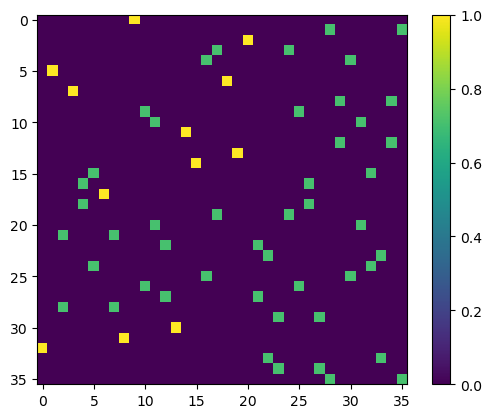

In [8]:
U1=np.loadtxt('support_60_perf_tensor_1.txt')
U1_R=U1.reshape([d,d,d,d]).transpose([0,2,1,3]).reshape(d**2,d**2)
U1_G=U1.reshape([d,d,d,d]).transpose([0,3,2,1]).reshape(d**2,d**2)
print(r'||la.norm(U1U1^{\dagger}-I_36||= ',la.norm(U1@np.conj(U1.T)-np.eye(d**2)))          # unitarity of U
print(r'||la.norm(U1_RU1_R^{\dagger}-I_36||= ',la.norm(U1_R@np.conj(U1_R.T)-np.eye(d**2)))  # unitarity of U_R
print(r'||la.norm(U1_GU1_G^{\dagger}-I_36||= ',la.norm(U1_G@np.conj(U1_G.T)-np.eye(d**2)))  # unitarity of U_T 
plt.imshow(abs(U1))
plt.colorbar()
plt.show()

||la.norm(U2U2^{\dagger}-I_36||=  1.0932989485744118e-15
||la.norm(U2_RU2_R^{\dagger}-I_36||=  1.0932989485744118e-15
||la.norm(U2_GU2_G^{\dagger}-I_36||=  1.0932989485744118e-15


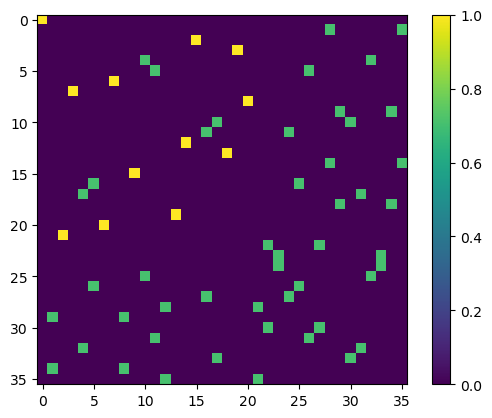

In [10]:
U2=np.loadtxt('support_60_perf_tensor_2.txt')
U2_R=U2.reshape([d,d,d,d]).transpose([0,2,1,3]).reshape(d**2,d**2)
U2_G=U2.reshape([d,d,d,d]).transpose([0,3,2,1]).reshape(d**2,d**2)
print(r'||la.norm(U2U2^{\dagger}-I_36||= ',la.norm(U2@np.conj(U2.T)-np.eye(d**2)))               # unitarity of U
print(r'||la.norm(U2_RU2_R^{\dagger}-I_36||= ',la.norm(U2_R@np.conj(U2_R.T)-np.eye(d**2)))       # unitarity of U_R
print(r'||la.norm(U2_GU2_G^{\dagger}-I_36||= ',la.norm(U2_G@np.conj(U2_G.T)-np.eye(d**2)))       # unitarity of U_T
plt.imshow(abs(U2))
plt.colorbar()
plt.show()

# Non-zero entries and block structure of representatives of the support-60 perfect tensors:
## (1) Perfect tensor $\mathcal{U}$; $6\times 2+6\times 4=36$
The 60 non-zero entries in $\mathcal{U}$ can be arranged (up to permutations) into six blocks each of size 2 and six blocks each of size 4 as shown below.

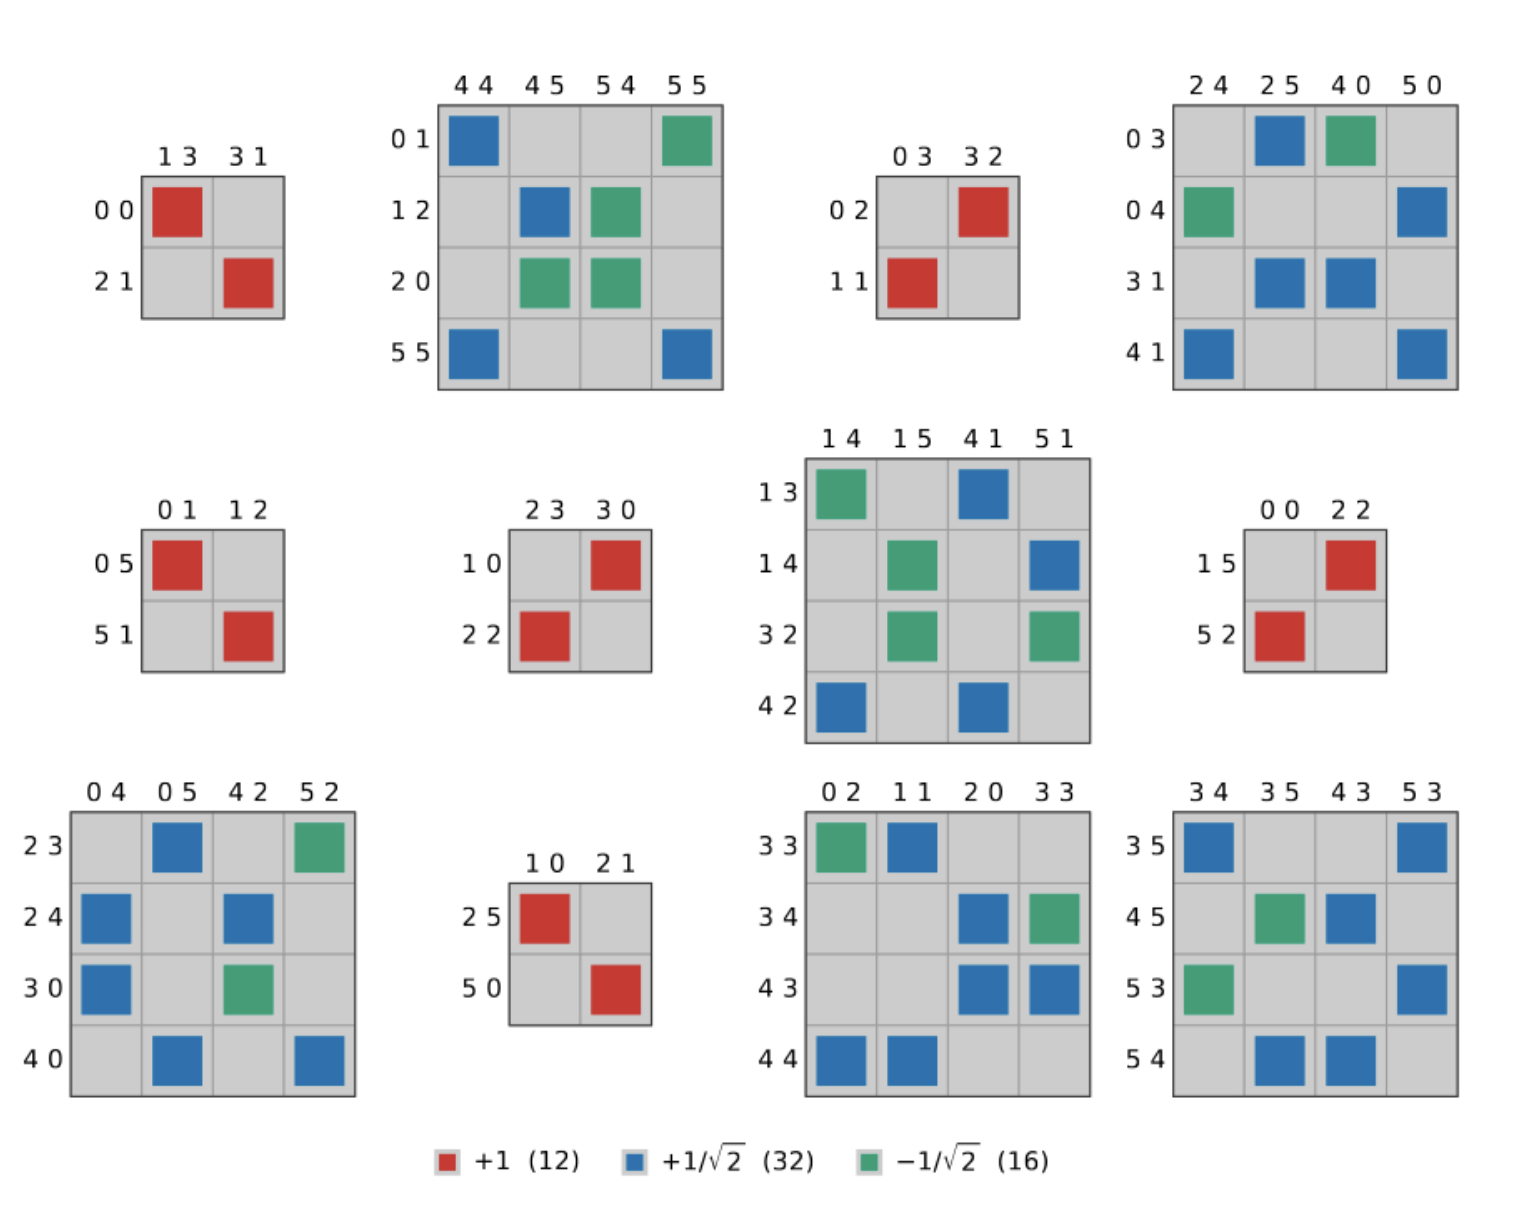

## (2) Perfect tensor $\mathcal{U}'$; $8\times 1+14\times 2=36$
The 60 non-zero entries in $\mathcal{U}$ can be arranged (up to permutations) into eight blocks each of size 1 and fourteen blocks each of size 2.

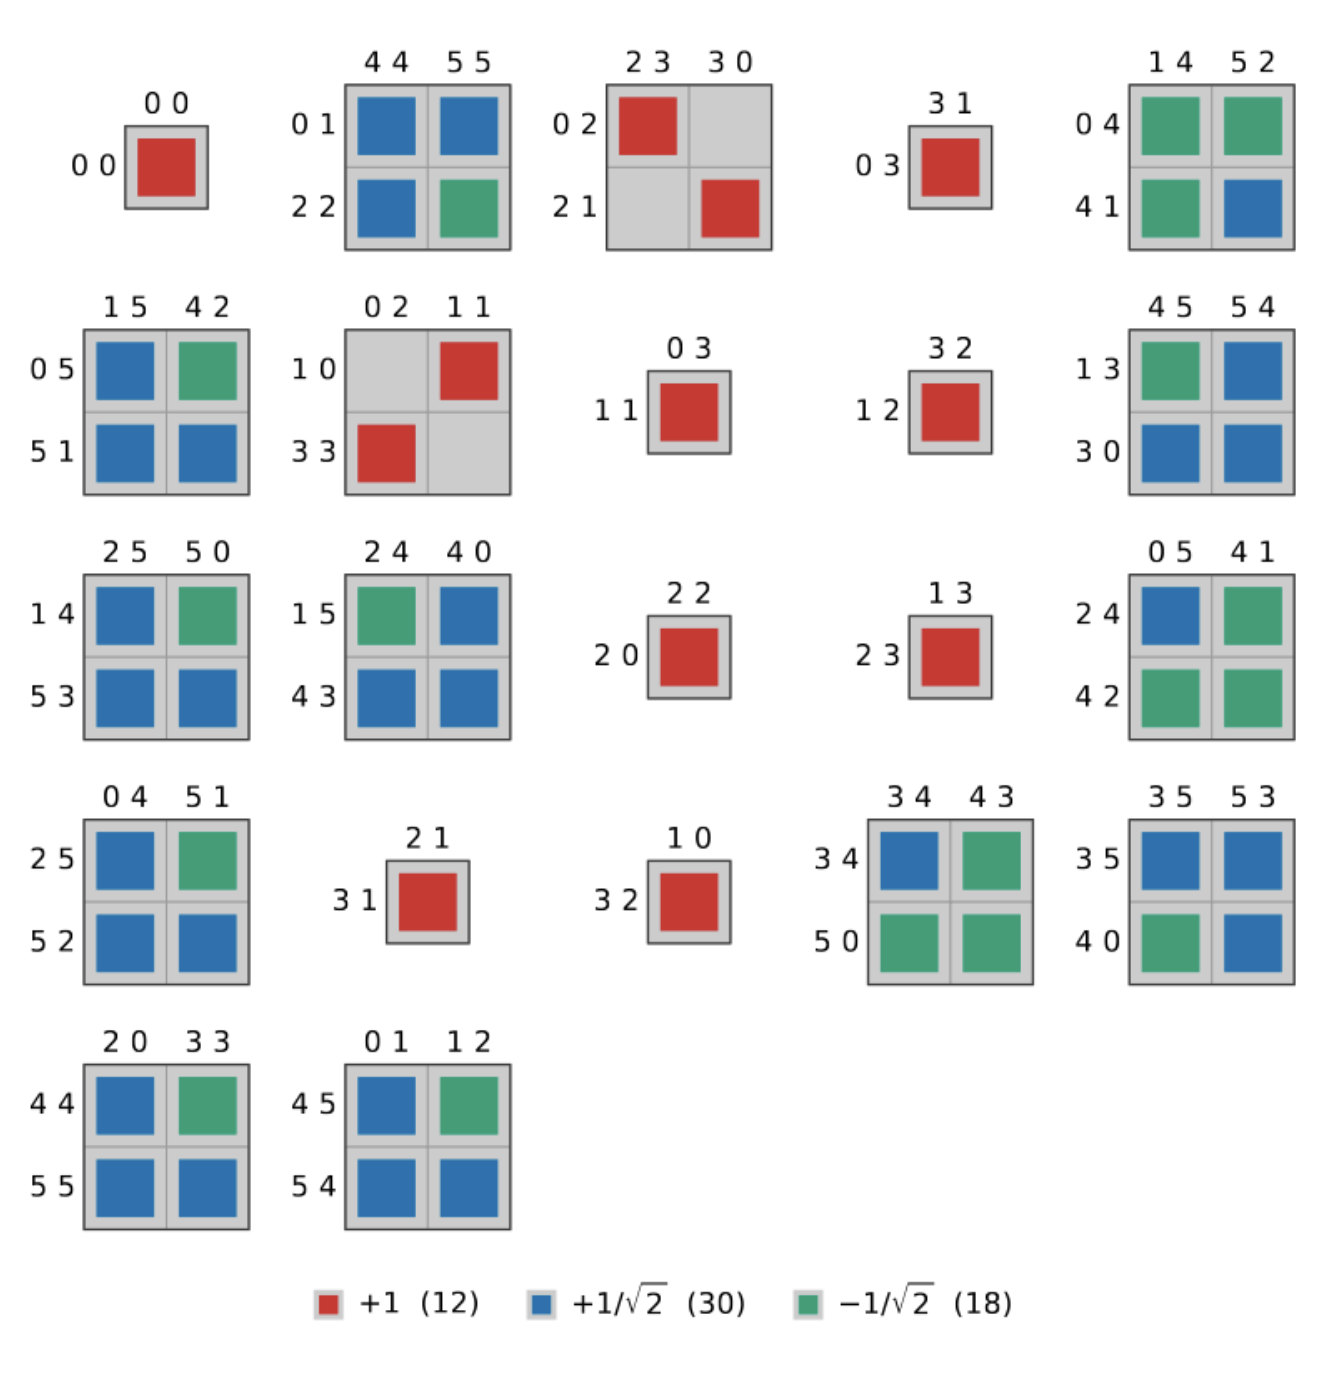

Using the invariants of LU equivalence and tangent space dimension analysis, it can be shown that $\mathcal{U}$ and $\mathcal{U}'$ are not local unitarily equivalent which is also suggestive from their block staructure.

# Conclusion: Rank-four perfect tensors in dimension six or, equivalently, AME(4,6) state with only real-valued entries exist, and remarkable there exist representations in which there are only 60 non-zero coefficients out of total $6^4=1296$ in the product (computational) basis.